In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look clean
sns.set_style("whitegrid")

In [30]:
df2007 = pd.read_csv("../data/T20 World Cup 2007 matches.csv")
df2009 = pd.read_csv("../data/T20 World Cup 2009 matches.csv")
df2010 = pd.read_csv("../data/T20 World Cup 2010 matches.csv")
df2012 = pd.read_csv("../data/T20 World Cup 2012 matches.csv")
df2014 = pd.read_csv("../data/T20 World Cup 2014 matches.csv")
df2016 = pd.read_csv("../data/T20 World Cup 2016 matches.csv")
df2021 = pd.read_csv("../data/T20 World Cup 2021 matches.csv")

In [31]:
df2007.head()

,Match No,Date,Group/Semi Final/Final,Match Between,Venue,Winning Team Score,Losing Team Score,Winner Team,Result,Player Of The Match
0,1,2007-11-09,Group A,South Africa vs West Indies,"The Wanderers Stadium, Johannesburg",208/2(17.4 overs),205/6(20 overs),South Africa,South Africa won by 8 wickets,Chris Gayle
1,2,2007-12-09,Group C,Kenya vs New Zealand,"Kingsmead, Durban",74/1(7.4 overs),73(16.5 overs),New Zealand,New Zealand won by 9 wickets,Mark Gillespie
2,3,2007-12-09,Group D,Pakistan vs Scotland,"Kingsmead, Durban",171/9(20 overs),120(19.5 overs),Pakistan,Pakistan won by 51 runs,Shahid Afridi
3,4,2007-12-09,Group B,Australia vs Zimbabwe,"Newlands, Cape Town",139/5(19.5 overs),138/9(20 overs),Zimbabwe,Zimbabwe won by 5 wickets,Brendan Taylor
4,5,2007-09-13,Group A,Bangladesh vs West Indies,"The Wanderers Stadium, Johannesburg",165/4(18 overs),164/8(20 overs),Bangladesh,Bangladesh won by 6 wickets,Mohammad Ashraful


In [32]:
df2007["Year"] = 2007
df2009["Year"] = 2009
df2010["Year"] = 2010
df2012["Year"] = 2012
df2014["Year"] = 2014
df2016["Year"] = 2016
df2021["Year"] = 2021

In [33]:
df = pd.concat([df2007, df2009, df2010, df2012, df2014, df2016, df2021], ignore_index=True)

In [34]:
df.head()

,Match No,Date,Group/Semi Final/Final,Match Between,Venue,Winning Team Score,Losing Team Score,Winner Team,Result,Player Of The Match,Year,Group/Super Eights/Semi Final/Final
0,1,2007-11-09,Group A,South Africa vs West Indies,"The Wanderers Stadium, Johannesburg",208/2(17.4 overs),205/6(20 overs),South Africa,South Africa won by 8 wickets,Chris Gayle,2007,NaN
1,2,2007-12-09,Group C,Kenya vs New Zealand,"Kingsmead, Durban",74/1(7.4 overs),73(16.5 overs),New Zealand,New Zealand won by 9 wickets,Mark Gillespie,2007,NaN
2,3,2007-12-09,Group D,Pakistan vs Scotland,"Kingsmead, Durban",171/9(20 overs),120(19.5 overs),Pakistan,Pakistan won by 51 runs,Shahid Afridi,2007,NaN
3,4,2007-12-09,Group B,Australia vs Zimbabwe,"Newlands, Cape Town",139/5(19.5 overs),138/9(20 overs),Zimbabwe,Zimbabwe won by 5 wickets,Brendan Taylor,2007,NaN
4,5,2007-09-13,Group A,Bangladesh vs West Indies,"The Wanderers Stadium, Johannesburg",165/4(18 overs),164/8(20 overs),Bangladesh,Bangladesh won by 6 wickets,Mohammad Ashraful,2007,NaN


In [35]:
df.shape

(223, 12)

In [36]:
df.columns

Index(['Match No', 'Date', 'Group/Semi Final/Final', 'Match Between', 'Venue',
       'Winning Team Score', 'Losing Team Score', 'Winner Team', 'Result',
       'Player Of The Match', 'Year', 'Group/Super Eights/Semi Final/Final'],
      dtype='str')

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Match No                             223 non-null    int64
 1   Date                                 223 non-null    str  
 2   Group/Semi Final/Final               196 non-null    str  
 3   Match Between                        223 non-null    str  
 4   Venue                                223 non-null    str  
 5   Winning Team Score                   221 non-null    str  
 6   Losing Team Score                    219 non-null    str  
 7   Winner Team                          218 non-null    str  
 8   Result                               223 non-null    str  
 9   Player Of The Match                  218 non-null    str  
 10  Year                                 223 non-null    int64
 11  Group/Super Eights/Semi Final/Final  27 non-null     str  
dtypes: in

In [38]:
df.isnull().sum()

Match No                                 0
Date                                     0
Group/Semi Final/Final                  27
Match Between                            0
Venue                                    0
Winning Team Score                       2
Losing Team Score                        4
Winner Team                              5
Result                                   0
Player Of The Match                      5
Year                                     0
Group/Super Eights/Semi Final/Final    196
dtype: int64

In [39]:
df = df.drop(columns=["Group/Super Eights/Semi Final/Final"])

In [40]:
df["Winning Team Score"] = pd.to_numeric(df["Winning Team Score"], errors="coerce")
df["Losing Team Score"] = pd.to_numeric(df["Losing Team Score"], errors="coerce")

In [41]:
df["Group/Semi Final/Final"] = df["Group/Semi Final/Final"].fillna("Group")

In [42]:
df = df.dropna(subset=["Winner Team", "Player Of The Match"])

In [43]:
df.isnull().sum()

Match No                    0
Date                        0
Group/Semi Final/Final      0
Match Between               0
Venue                       0
Winning Team Score        218
Losing Team Score         218
Winner Team                 0
Result                      0
Player Of The Match         0
Year                        0
dtype: int64

In [44]:
df = df.drop(columns=["Winning Team Score", "Losing Team Score"])

In [45]:
df.isnull().sum()

Match No                  0
Date                      0
Group/Semi Final/Final    0
Match Between             0
Venue                     0
Winner Team               0
Result                    0
Player Of The Match       0
Year                      0
dtype: int64

In [46]:
df["Year"].value_counts().sort_index()

Year
2007    26
2009    27
2010    26
2012    26
2014    35
2016    33
2021    45
Name: count, dtype: int64

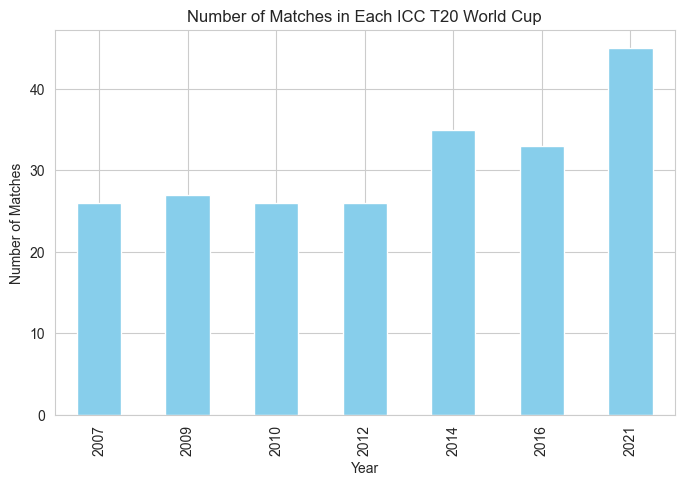

In [47]:
plt.figure(figsize=(8,5))

df["Year"].value_counts().sort_index().plot(kind="bar", color="skyblue")

plt.title("Number of Matches in Each ICC T20 World Cup")
plt.xlabel("Year")
plt.ylabel("Number of Matches")

plt.show()

### Observation

The number of matches played in ICC T20 World Cups has gradually increased over time.
Earlier tournaments had around 26–27 matches, while the 2021 edition had the highest
number of matches (45), reflecting the expansion of teams and tournament format.

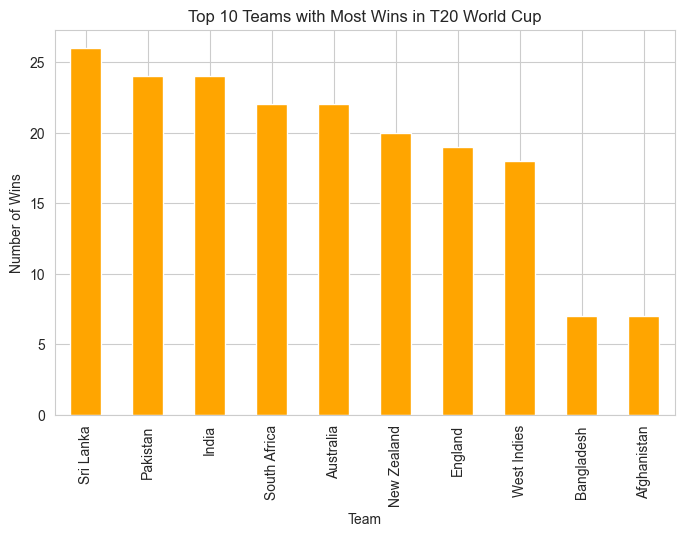

In [48]:
top_teams = df["Winner Team"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_teams.plot(kind="bar", color="orange")

plt.title("Top 10 Teams with Most Wins in T20 World Cup")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.show()

In [49]:
top_players = df["Player Of The Match"].value_counts().head(10)

top_players

Player Of The Match
Chris Gayle             5
Mahela Jayawardene      5
Shane Watson            5
Virat Kohli             5
Shahid Afridi           4
AB de Villiers          4
Tillakaratne Dilshan    4
Kevin Pietersen         3
Sanath Jayasuriya       3
Yuvraj Singh            3
Name: count, dtype: int64

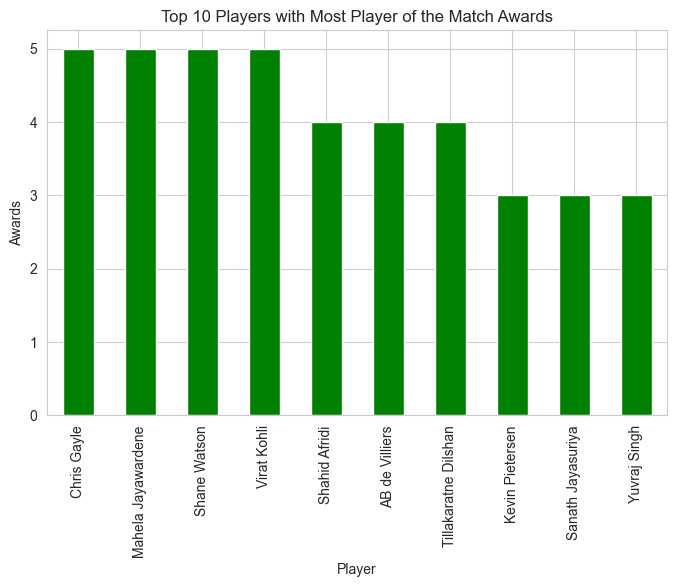

In [50]:
plt.figure(figsize=(8,5))

top_players.plot(kind="bar", color="green")

plt.title("Top 10 Players with Most Player of the Match Awards")
plt.xlabel("Player")
plt.ylabel("Awards")

plt.show()

### Observation

Several players such as Chris Gayle, Mahela Jayawardene, Shane Watson, and Virat Kohli
have consistently delivered outstanding performances in ICC T20 World Cup matches.
Their multiple Player of the Match awards highlight their significant impact
in crucial games across different tournaments.

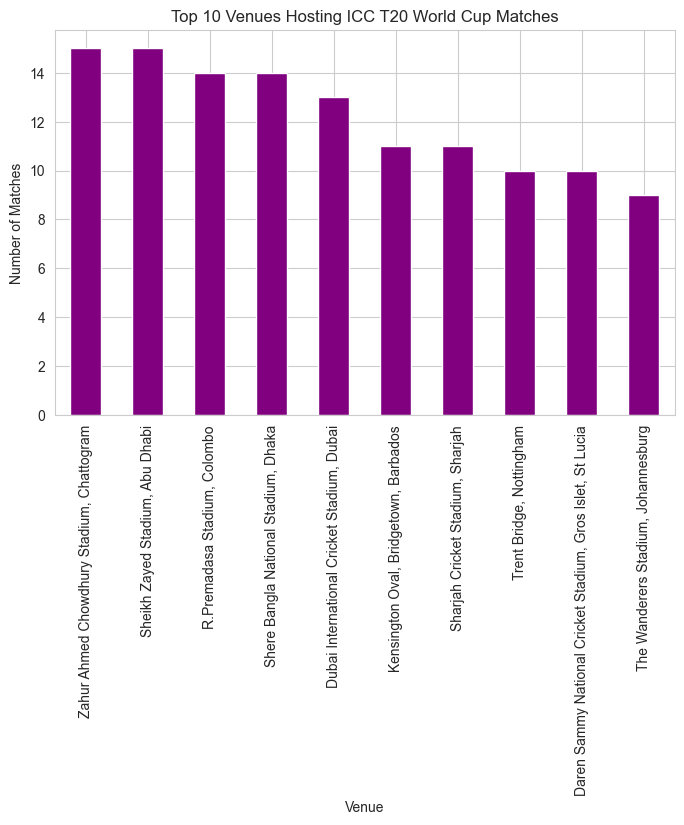

In [51]:
top_venues = df["Venue"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_venues.plot(kind="bar", color="purple")

plt.title("Top 10 Venues Hosting ICC T20 World Cup Matches")
plt.xlabel("Venue")
plt.ylabel("Number of Matches")

plt.show()

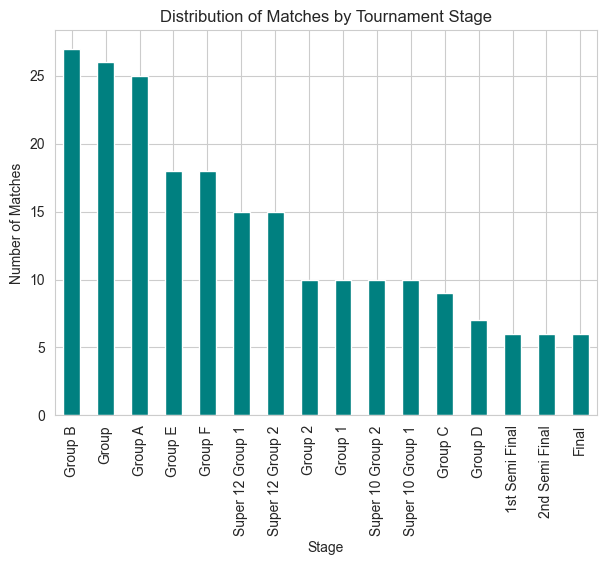

In [52]:
stage_counts = df["Group/Semi Final/Final"].value_counts()

plt.figure(figsize=(7,5))
stage_counts.plot(kind="bar", color="teal")

plt.title("Distribution of Matches by Tournament Stage")
plt.xlabel("Stage")
plt.ylabel("Number of Matches")

plt.show()

### Observation

Most matches in ICC T20 World Cups occur during the group stage,
while semi-finals and finals represent the knockout rounds that
determine the tournament champion.

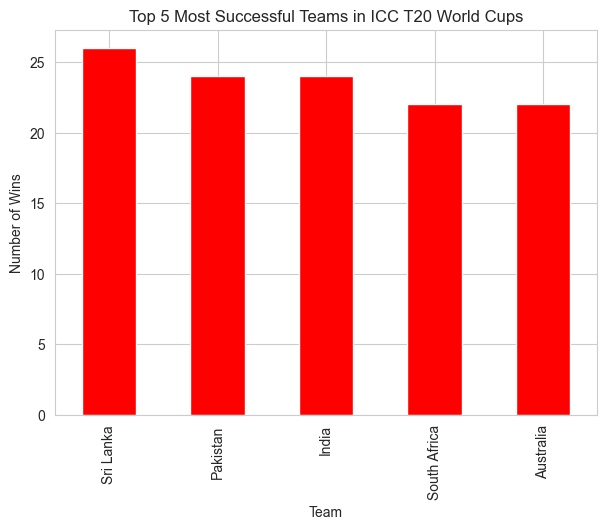

In [53]:
top5_teams = df["Winner Team"].value_counts().head(5)

plt.figure(figsize=(7,5))
top5_teams.plot(kind="bar", color="red")

plt.title("Top 5 Most Successful Teams in ICC T20 World Cups")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.show()

### Observation

A few teams consistently dominate ICC T20 World Cup tournaments.
These teams maintain strong performance across multiple editions,
highlighting their depth in batting, bowling, and match strategy.

## Conclusion

This project analyzed ICC T20 World Cup match data from 2007 to 2021 to uncover key trends and insights.

Key findings from the analysis include:

• The number of matches has increased over time as the tournament expanded.  
• Certain teams have consistently performed well and secured the most victories.  
• Several players have delivered match-winning performances multiple times, earning numerous Player of the Match awards.  
• Some venues have hosted significantly more matches than others.  
• Most matches occur during the group stage, while knockout stages determine the final champion.

Overall, this analysis demonstrates how data analytics can be used to understand patterns in sports performance and tournament structures.